# CREDIT CARD FRAUD DETECTION (MODELLING)

### Installing local dependancies 

In [2]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Models
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier

# Imbalance handling
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

# Tuning
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

### loading dataset 

In [3]:
balanced_data = pd.read_csv("Data_set/balanced_creditcard.csv")


balanced_data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,77970.0,1.222435,-0.482973,1.006126,-0.629278,-1.545401,-1.058787,-0.699653,0.058106,2.098220,...,-0.013621,0.112532,0.028354,0.681553,0.389823,-0.700175,0.081159,0.034358,1.00,0
1,77720.0,1.372852,-0.600069,-1.982242,-1.652596,1.875989,2.850328,-0.650839,0.633996,-1.195478,...,0.085969,-0.090311,-0.211467,0.957720,0.811915,-0.137130,-0.013380,0.031342,69.79,0
2,125612.0,1.889618,1.073099,-1.678018,4.173268,1.015516,-0.009389,-0.079706,0.064071,-0.714517,...,0.203728,0.733796,-0.036560,0.334306,0.147171,0.279556,0.031669,0.035883,3.22,1
3,164489.0,0.039062,0.889239,0.302199,-0.585161,0.431838,-1.116524,1.050711,-0.232965,-0.109813,...,-0.253421,-0.535450,0.072419,0.050588,-0.475029,0.136236,0.248946,0.098623,5.99,0
4,146267.0,-0.629286,1.379787,-0.297018,-1.393297,1.489655,-0.885139,1.872444,-0.523914,-0.590964,...,0.158709,0.782369,-0.492603,0.834802,0.546616,0.155325,0.091849,0.002683,7.57,0


### Train-Test Split the data first 

In [4]:
X = balanced_data.drop("Class", axis=1)
y = balanced_data["Class"]  


# Split the data into training and testing sets with stratification to maintain class distribution
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

print("\nClass distribution in original data:")
print(y.value_counts(normalize=True))
print("\nClass distribution in y_train:")
print(y_train.value_counts(normalize=True))
print("\nClass distribution in y_test:")
print(y_test.value_counts(normalize=True))
#### Removed skewdness from the data

Shape of X_train: (756, 30)
Shape of X_test: (190, 30)
Shape of y_train: (756,)
Shape of y_test: (190,)

Class distribution in original data:
Class
0    0.5
1    0.5
Name: proportion, dtype: float64

Class distribution in y_train:
Class
0    0.5
1    0.5
Name: proportion, dtype: float64

Class distribution in y_test:
Class
1    0.5
0    0.5
Name: proportion, dtype: float64


In [5]:
# Manual Z-Score Cleaning (Test set only)

import numpy as np
from scipy.stats import zscore

#  Manual Z-Score Cleaning (Train set only)
z_scores = np.abs(zscore(X_train))
mask = (z_scores < 3).all(axis=1)
X_train_cleaned = X_train[mask]
y_train_cleaned = y_train[mask]

* Now we have split dataset that has been manually skewed ready for the model 

### Modelling

#### Build the KNN model first

In [6]:
pipeline_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE()),
    ('knn', KNeighborsClassifier())
])

#### cross-validating the KNN model 

* so th

In [7]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(
    pipeline_knn,
    X_train_cleaned,
    y_train_cleaned,
    cv=cv,
    scoring='f1'
)

print("KNN CV F1 scores:", scores)
print("Mean F1:", scores.mean())

KNN CV F1 scores: [0.90384615 0.89908257 0.88235294 0.87272727 0.92307692]
Mean F1: 0.8962171719268319


* visu

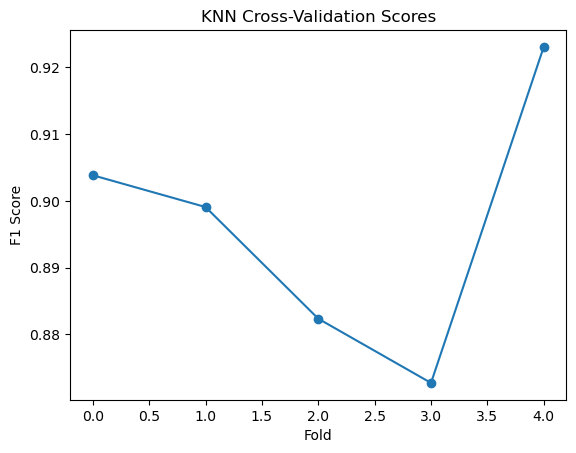

<Figure size 640x480 with 0 Axes>

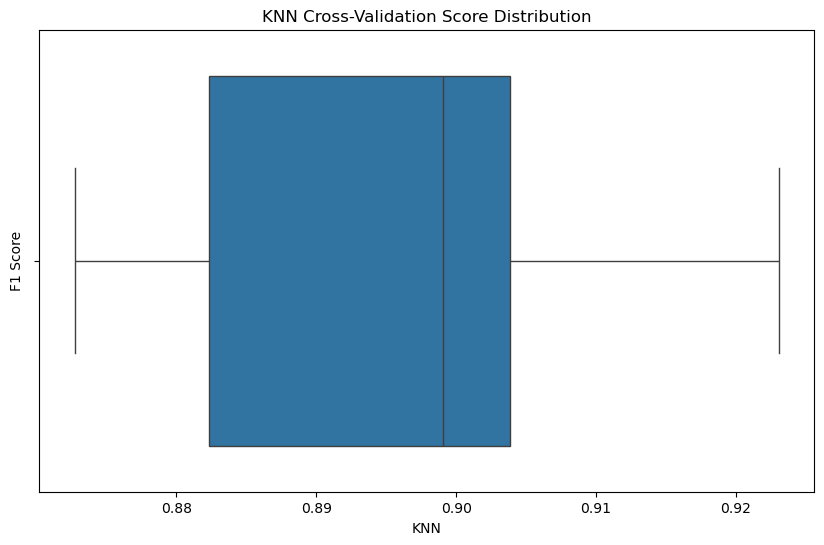

<Figure size 640x480 with 0 Axes>

In [8]:
plt.plot(scores, marker='o')
plt.title("KNN Cross-Validation Scores")
plt.xlabel("Fold")
plt.ylabel("F1 Score")
plt.show()
plt.savefig("model visuals/knn_cv_scores_line.png")

plt.figure(figsize=(10, 6))
sns.boxplot(x=scores)
plt.title("KNN Cross-Validation Score Distribution")
plt.xlabel("KNN")
plt.ylabel("F1 Score")
plt.show()
plt.savefig("model visuals/knn_cv_scores.png")


### Hyperparameter Tuning (KNN)

In [10]:
param_grid = {
    'knn__n_neighbors': [3,5,7,11],
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan']
}

grid_knn = GridSearchCV(
    pipeline_knn,
    param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1
)

grid_knn.fit(X_train, y_train)

print("Best Params:", grid_knn.best_params_)
print("Best CV Score:", grid_knn.best_score_)

Best Params: {'knn__metric': 'manhattan', 'knn__n_neighbors': 11, 'knn__weights': 'distance'}
Best CV Score: 0.9159994751693883


### Final Evaluation (KNN)

In [11]:
best_knn = grid_knn.best_estimator_

y_pred_knn = best_knn.predict(X_test)

print(classification_report(y_test, y_pred_knn))
print("ROC AUC:", roc_auc_score(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       0.86      1.00      0.92        95
           1       1.00      0.83      0.91        95

    accuracy                           0.92       190
   macro avg       0.93      0.92      0.92       190
weighted avg       0.93      0.92      0.92       190

ROC AUC: 0.9157894736842105


####  CONFUSION MTRIX FOR KNN

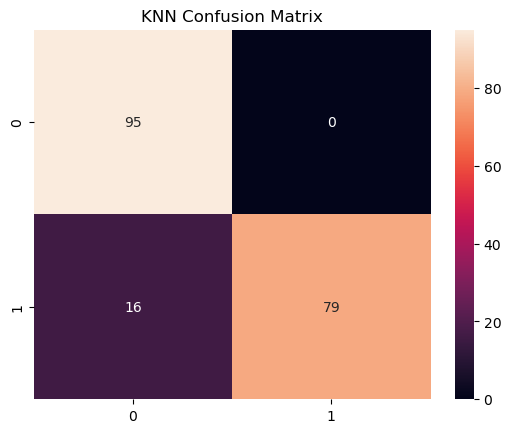

<Figure size 640x480 with 0 Axes>

In [12]:
sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True, fmt='d')
plt.title("KNN Confusion Matrix")
plt.show()
plt.savefig("model visuals/knn_confusion_matrix.png")

* FN (missed fraud) = most dangerous

#### LOGREGRESSION MODEL

In [9]:
# Initialize the Logistic Regression model
log_reg_model = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' solver is good for small datasets

# Train the model
log_reg_model.fit(X_train_cleaned, y_train_cleaned)

# Make predictions on the test set
y_pred_log_reg = log_reg_model.predict(X_test)

print("First 5 predictions:")
print(y_pred_log_reg[:5])

First 5 predictions:
[1 0 1 0 1]


#### PIPELINE LOG REGRESSION

In [15]:
pipeline_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE()),
    ('lr', LogisticRegression(max_iter=1000))
])

#unvlidated code, just to check if it runs without error

pipeline_lr.fit(X_train_cleaned, y_train_cleaned)
ypred_logunvl = pipeline_lr.predict(X_test)

print(f"First 5 predictions from unvlidted pipeline: {ypred_logunvl[:5]}" )

scores_lr = cross_val_score(
    pipeline_lr,
    X_train,
    y_train,
    cv=cv,
    scoring='f1'
)

print("Logistic Regression CV F1:", scores_lr.mean())
print("Logistic Regression CV Scores:", scores_lr[:5])

First 5 predictions from unvlidted pipeline: [1 0 1 0 1]
Logistic Regression CV F1: 0.9322930601650489
Logistic Regression CV Scores: [0.93150685 0.90909091 0.93055556 0.95238095 0.93793103]
